In [2]:
from google.colab import drive
drive.mount('/content/drive') 

Mounted at /content/drive


In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [15]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# 1. Caminho direto apontando para a entrada do Kaggle
dataset_path = '/kaggle/input/skin-cancer-mnist-ham10000'
csv_path = os.path.join(dataset_path, 'HAM10000_metadata.csv')

# 2. Carrega o CSV original
df_csv = pd.read_csv(csv_path)

# 3. Escaneia o diretório para mapear onde estão os arquivos físicos de imagem
mapeamento_real = {}
for raiz, dirs, arquivos in os.walk(dataset_path):
    for arquivo in arquivos:
        if arquivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            id_imagem = os.path.splitext(arquivo)[0]
            mapeamento_real[id_imagem] = os.path.join(raiz, arquivo)

# 4. Vincula o CSV com os caminhos reais encontrados no disco
dados_finais = []
for idx, linha in df_csv.iterrows():
    id_img = linha['image_id']
    if id_img in mapeamento_real:
        dados_finais.append({
            'image_id': id_img,
            'image_path': mapeamento_real[id_img],
            'dx': linha['dx']
        })

df = pd.DataFrame(dados_finais)

# 5. Validação do mapeamento
if len(df) == 0:
    print("❌ Erro: Não foi possível encontrar as imagens nesse diretório. Verifique se a pasta está correta.")
else:
    print(f"✅ Sucesso Absoluto! Encontramos {len(df)} imagens no caminho informado.")
    df['label_idx'] = pd.Categorical(df['dx']).codes
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_idx'])

✅ Sucesso Absoluto! Encontramos 10015 imagens no caminho informado.


In [22]:
import tensorflow as tf

IMG_SIZE = [224, 224]

def carregar_e_processar_classificacao(caminho_img, label):
    # 1. Ler o arquivo binário
    img_raw = tf.io.read_file(caminho_img)
    
    # 2. Decodificar garantindo 3 canais (RGB)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    
    # 3. Redimensionar para o tamanho da rede
    img = tf.image.resize(img, [224, 224])
    
    # 4. Normalizar dividindo por 255.0 manualmente (Garante float32 limpo entre 0 e 1)
    img = img / 255.0
    
    return img, label

batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label_idx'].values))
train_dataset = train_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_df['image_path'].values, val_df['label_idx'].values))
val_dataset = val_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

print("✅ Pipelines do tf.data atualizados com sucesso!")

✅ Pipelines do tf.data atualizados com sucesso!


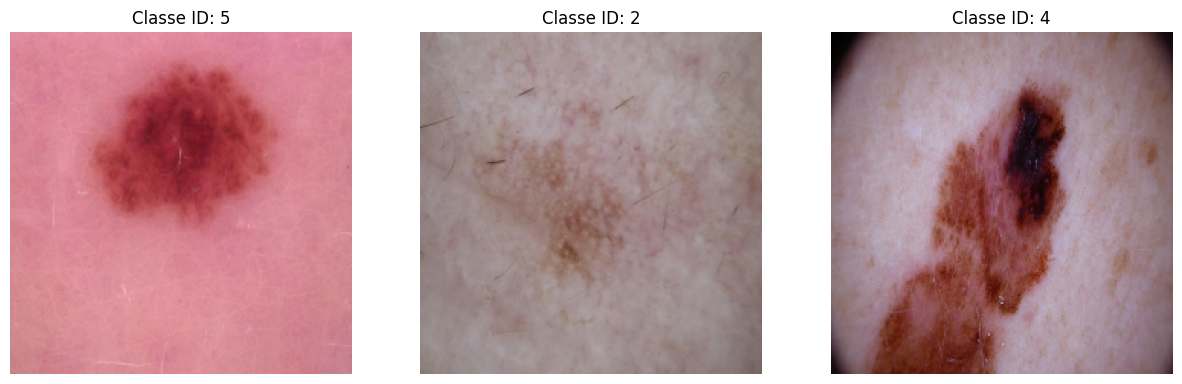

In [23]:
import matplotlib.pyplot as plt

for imagens_lote, labels_lote in train_dataset.take(1):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
    for i in range(3):
        # Como img agora é float32 entre 0 e 1 puro, o matplotlib lê direto sem truques
        axes[i].imshow(imagens_lote[i].numpy())
        axes[i].set_title(f"Classe ID: {labels_lote[i].numpy()}")
        axes[i].axis('off')
    plt.show()

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Carregar a base pré-treinada (sem a camada final de 1000 classes do ImageNet)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Congelamos os pesos da base para o treino focar apenas nos nossos neurônios novos
base_model.trainable = False

# 2. Construir o topo da nossa rede (Cabeça de Classificação)
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Reduz os mapas de feições a um vetor de 1D
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4), # Evita overfitting mascarando 40% dos neurônios no treino
    layers.Dense(7, activation='softmax') # 7 saídas correspondentes às classes do HAM10000
])

# 3. Compilar o modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', # Usado porque nossos labels são inteiros (0 a 6)
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Configurar os Callbacks
callbacks = [
    # Interrompe o treino se a acurácia de validação parar de subir por 5 épocas seguidas
    EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True,
        verbose=1
    ),
    # Salva automaticamente o modelo no melhor ponto do treinamento
    ModelCheckpoint(
        filepath='melhor_modelo_ham10000.keras', 
        monitor='val_loss', 
        save_best_only=True,
        verbose=1
    )
]

# 2. Rodar o treinamento (Ajuste o número de épocas se preferir)
EPOCHS = 20

print("🚀 Iniciando o treinamento...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

🚀 Iniciando o treinamento...
Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.6574 - loss: 1.0527
Epoch 1: val_loss improved from None to 0.77189, saving model to melhor_modelo_ham10000.keras

Epoch 1: finished saving model to melhor_modelo_ham10000.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 367ms/step - accuracy: 0.6885 - loss: 0.9063 - val_accuracy: 0.7274 - val_loss: 0.7719
Epoch 2/20
249/251 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7317 - loss: 0.7628
Epoch 2: val_loss improved from 0.77189 to 0.72298, saving model to melhor_modelo_ham10000.keras

Epoch 2: finished saving model to melhor_modelo_ham10000.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 228ms/step - accuracy: 0.7330 - loss: 0.7552 - val_accuracy: 0.7399 - val_loss: 0.7230
Epoch 3/20
249/251 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7448 - loss: 0.7211
Epoch 3: val_loss improved from 0.72298 to 0.70837, saving model to melhor_modelo_ham10000.keras

Epoch 3: finished saving model to melhor_modelo_h